In [1]:
# =============================================================================
# CELL 1: Download MGCD from Google Drive
# =============================================================================
!pip install -q gdown openpyxl

import gdown
import zipfile
import os
import shutil

# Dataset info
print("📦 MGCD - Multimodal Ground-based Cloud Database")
print("   • 8,000 fisheye images at 1024×1024")
print("   • 7 classes (WMO-based)")
print("   • Pre-split: 4,000 train / 4,000 test")
print("   • MULTIMODAL: Images + Weather data (temp, humidity, pressure, wind)")
print("   • Camera: Fisheye lens (circular sky dome)")
print()

# Download
GDRIVE_ID = "17PBT__KLwJuAsUMSxnByGWaBkMaxGh4i"
ZIP_FILE = "MGCD.zip"
EXTRACT_DIR = "/content/MGCD_dataset"

print("⬇️ Downloading (~575MB)...")
gdown.download(f"https://drive.google.com/uc?id={GDRIVE_ID}", ZIP_FILE, quiet=False)

# Extract
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

print("\n📂 Extracting...")
with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# Show structure
print("\n📁 Folder structure:")
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        for d in sorted(dirs)[:10]:
            print(f"{indent}  {d}/")

print("\n✅ Ready! Run next cell.")

📦 MGCD - Multimodal Ground-based Cloud Database
   • 8,000 fisheye images at 1024×1024
   • 7 classes (WMO-based)
   • Pre-split: 4,000 train / 4,000 test
   • MULTIMODAL: Images + Weather data (temp, humidity, pressure, wind)
   • Camera: Fisheye lens (circular sky dome)

⬇️ Downloading (~575MB)...


Downloading...
From (original): https://drive.google.com/uc?id=17PBT__KLwJuAsUMSxnByGWaBkMaxGh4i
From (redirected): https://drive.google.com/uc?id=17PBT__KLwJuAsUMSxnByGWaBkMaxGh4i&confirm=t&uuid=f9e09aae-0694-48df-b4af-c5f825f8549e
To: /content/MGCD.zip
100%|██████████| 575M/575M [00:06<00:00, 86.9MB/s]



📂 Extracting...

📁 Folder structure:
MGCD_dataset/
  MGCD/
  MGCD/
    test/
    train/
    train/
      1_cumulus/
      2_altocumulus/
      3_cirrus/
      4_clearsky/
      5_stratocumulus/
      6_cumulonimbus/
      7_mixed/
    test/
      1_cumulus/
      2_altocumulus/
      3_cirrus/
      4_clearsky/
      5_stratocumulus/
      6_cumulonimbus/
      7_mixed/

✅ Ready! Run next cell.


In [2]:
# =============================================================================
# CELL 2: Set Paths & Count Class Distribution
# =============================================================================
import os
import pandas as pd

# Set paths
BASE_PATH = "/content/MGCD_dataset/MGCD"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
TEST_PATH = os.path.join(BASE_PATH, "test")

# Get class names (folders only, not xlsx files)
CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_PATH)
                      if os.path.isdir(os.path.join(TRAIN_PATH, d))])

print(f"✅ BASE_PATH: {BASE_PATH}")
print(f"✅ Found {len(CLASS_NAMES)} classes:\n")

# Count images per class
train_counts = {}
test_counts = {}

print(f"{'Class':<25} {'Train':>8} {'Test':>8} {'Total':>8}")
print("-" * 55)

for cls in CLASS_NAMES:
    train_n = len([f for f in os.listdir(os.path.join(TRAIN_PATH, cls))
                   if f.endswith('.jpg')])
    test_n = len([f for f in os.listdir(os.path.join(TEST_PATH, cls))
                  if f.endswith('.jpg')])
    train_counts[cls] = train_n
    test_counts[cls] = test_n
    print(f"{cls:<25} {train_n:>8} {test_n:>8} {train_n+test_n:>8}")

print("-" * 55)
total_train = sum(train_counts.values())
total_test = sum(test_counts.values())
print(f"{'TOTAL':<25} {total_train:>8} {total_test:>8} {total_train+total_test:>8}")

# Imbalance check
max_cls = max(train_counts, key=train_counts.get)
min_cls = min(train_counts, key=train_counts.get)
imbalance = train_counts[max_cls] / train_counts[min_cls]

print(f"\n🔍 Imbalance ratio: {imbalance:.2f}x")
print(f"   Largest:  {max_cls} ({train_counts[max_cls]})")
print(f"   Smallest: {min_cls} ({train_counts[min_cls]})")

✅ BASE_PATH: /content/MGCD_dataset/MGCD
✅ Found 7 classes:

Class                        Train     Test    Total
-------------------------------------------------------
1_cumulus                      690      748     1438
2_altocumulus                  400      331      731
3_cirrus                       650      673     1323
4_clearsky                     650      688     1338
5_stratocumulus                500      463      963
6_cumulonimbus                 600      587     1187
7_mixed                        510      510     1020
-------------------------------------------------------
TOTAL                         4000     4000     8000

🔍 Imbalance ratio: 1.73x
   Largest:  1_cumulus (690)
   Smallest: 2_altocumulus (400)


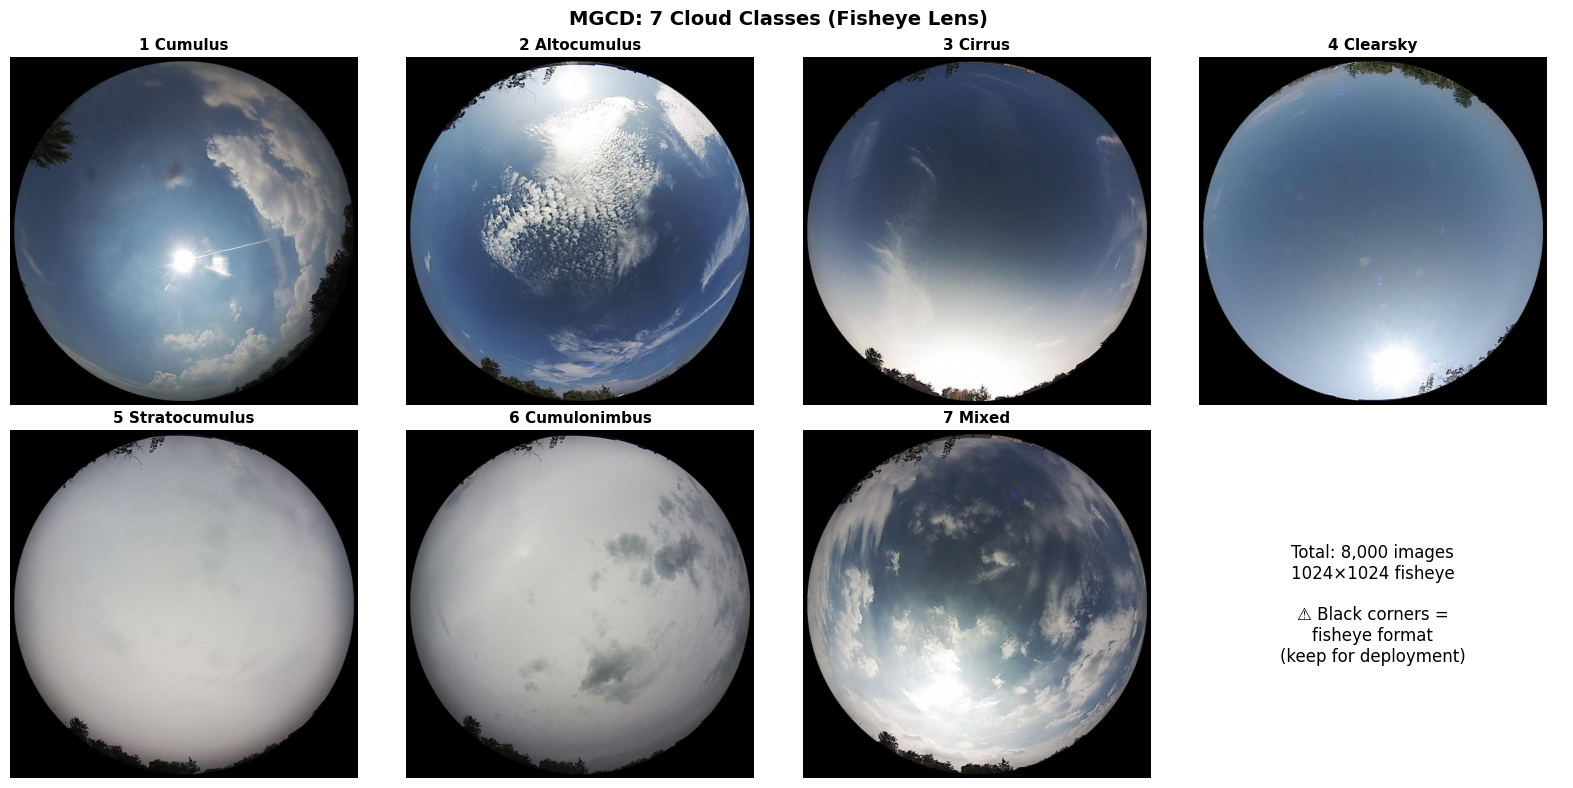


📐 Image properties:
   Resolution: (1024, 1024)
   Mode: RGB
   Format: JPEG


In [3]:
# =============================================================================
# CELL 3: Visualize Sample Images from Each Class
# =============================================================================
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_PATH, cls)
    img_files = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
    sample_img = random.choice(img_files)

    img = Image.open(os.path.join(cls_path, sample_img))

    axes[i].imshow(img)
    axes[i].set_title(cls.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].axis('off')

# Hide extra subplot
axes[7].axis('off')
axes[7].text(0.5, 0.5, f"Total: 8,000 images\n1024×1024 fisheye\n\n⚠️ Black corners =\nfisheye format\n(keep for deployment)",
             ha='center', va='center', fontsize=12, transform=axes[7].transAxes)

plt.suptitle('MGCD: 7 Cloud Classes (Fisheye Lens)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Check actual resolution - get fresh file list for first class
first_cls_path = os.path.join(TRAIN_PATH, CLASS_NAMES[0])
first_cls_files = [f for f in os.listdir(first_cls_path) if f.endswith('.jpg')]
sample_path = os.path.join(first_cls_path, first_cls_files[0])

with Image.open(sample_path) as img:
    print(f"\n📐 Image properties:")
    print(f"   Resolution: {img.size}")
    print(f"   Mode: {img.mode}")
    print(f"   Format: {img.format}")

In [4]:
# =============================================================================
# CELL 4: Explore Multimodal Weather Data (xlsx files)
# =============================================================================
import pandas as pd

# Each class has an xlsx file with weather data
# Let's see what's inside

sample_xlsx = os.path.join(TRAIN_PATH, "1_cumulus.xlsx")
df = pd.read_excel(sample_xlsx)

print("📊 MULTIMODAL WEATHER DATA STRUCTURE")
print("=" * 60)
print(f"\nColumns: {list(df.columns)}")
print(f"Rows: {len(df)} (one per image)")

print(f"\n🔍 Sample rows:")
print(df.head(3).to_string())

print(f"\n📈 Weather feature statistics (cumulus only):")
weather_cols = ['Temperature(℃)', 'Humidity(%RH)', 'Pressure(hpa)', 'Wind speed(m/s)']
print(df[weather_cols].describe().round(2).to_string())

print("""
\n💡 WHY THIS MATTERS:
   • Each image has paired weather measurements
   • Weather can help disambiguate visually similar clouds
   • Example: Cumulonimbus → high humidity (rain clouds)
   • Example: Clear sky → high pressure (stable weather)
""")

📊 MULTIMODAL WEATHER DATA STRUCTURE

Columns: ['Number', 'Name', 'Temperature(℃)', 'Humidity(%RH)', 'Pressure(hpa)', 'Wind speed(m/s)']
Rows: 690 (one per image)

🔍 Sample rows:
   Number              Name  Temperature(℃)  Humidity(%RH)  Pressure(hpa)  Wind speed(m/s)
0       1  1_cumulus_000001            32.6           66.8         1006.0              1.3
1       2  1_cumulus_000002            34.7           59.4         1006.0              0.0
2       3  1_cumulus_000003            33.9           63.9         1005.7              1.8

📈 Weather feature statistics (cumulus only):
       Temperature(℃)  Humidity(%RH)  Pressure(hpa)  Wind speed(m/s)
count          690.00         690.00         690.00           690.00
mean            35.08          57.40        1005.67             1.17
std              1.99           8.96           2.51             1.08
min             29.00          32.50        1002.40             0.00
25%             33.70          52.80        1003.50             0.4

In [5]:
# =============================================================================
# CELL 5: Weather Features Across ALL Classes
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# Load weather data from all classes
all_weather = []

for split in ['train', 'test']:
    split_path = os.path.join(BASE_PATH, split)
    for xlsx_file in os.listdir(split_path):
        if xlsx_file.endswith('.xlsx'):
            class_name = xlsx_file.replace('.xlsx', '')
            df = pd.read_excel(os.path.join(split_path, xlsx_file))
            df['class'] = class_name
            df['split'] = split
            all_weather.append(df)

weather_df = pd.concat(all_weather, ignore_index=True)
weather_cols = ['Temperature(℃)', 'Humidity(%RH)', 'Pressure(hpa)', 'Wind speed(m/s)']

print("📊 MEAN WEATHER VALUES BY CLOUD CLASS")
print("=" * 70)
class_means = weather_df.groupby('class')[weather_cols].mean().round(2)
print(class_means.to_string())

# Find most discriminative feature
print("\n" + "=" * 70)
print("🎯 WHICH FEATURE SEPARATES CLASSES BEST?")
print("=" * 70)

for col in weather_cols:
    means = weather_df.groupby('class')[col].mean()
    spread = means.max() - means.min()
    overall_std = weather_df[col].std()
    score = spread / overall_std  # higher = more discriminative

    print(f"\n{col}:")
    print(f"   Score: {score:.2f} (higher = better separator)")
    print(f"   Highest: {means.idxmax()} ({means.max():.1f})")
    print(f"   Lowest:  {means.idxmin()} ({means.min():.1f})")

📊 MEAN WEATHER VALUES BY CLOUD CLASS
                 Temperature(℃)  Humidity(%RH)  Pressure(hpa)  Wind speed(m/s)
class                                                                         
1_cumulus                 34.56          51.15        1005.88             1.04
2_altocumulus             29.53          52.14        1009.60             0.90
3_cirrus                  30.45          43.88        1008.93             0.70
4_clearsky                26.84          41.14        1012.83             1.10
5_stratocumulus           26.76          61.82        1008.80             0.87
6_cumulonimbus            28.39          75.55        1007.73             0.90
7_mixed                   31.75          57.96        1008.07             0.92

🎯 WHICH FEATURE SEPARATES CLASSES BEST?

Temperature(℃):
   Score: 1.37 (higher = better separator)
   Highest: 1_cumulus (34.6)
   Lowest:  5_stratocumulus (26.8)

Humidity(%RH):
   Score: 1.87 (higher = better separator)
   Highest: 6_cumulonimbus (

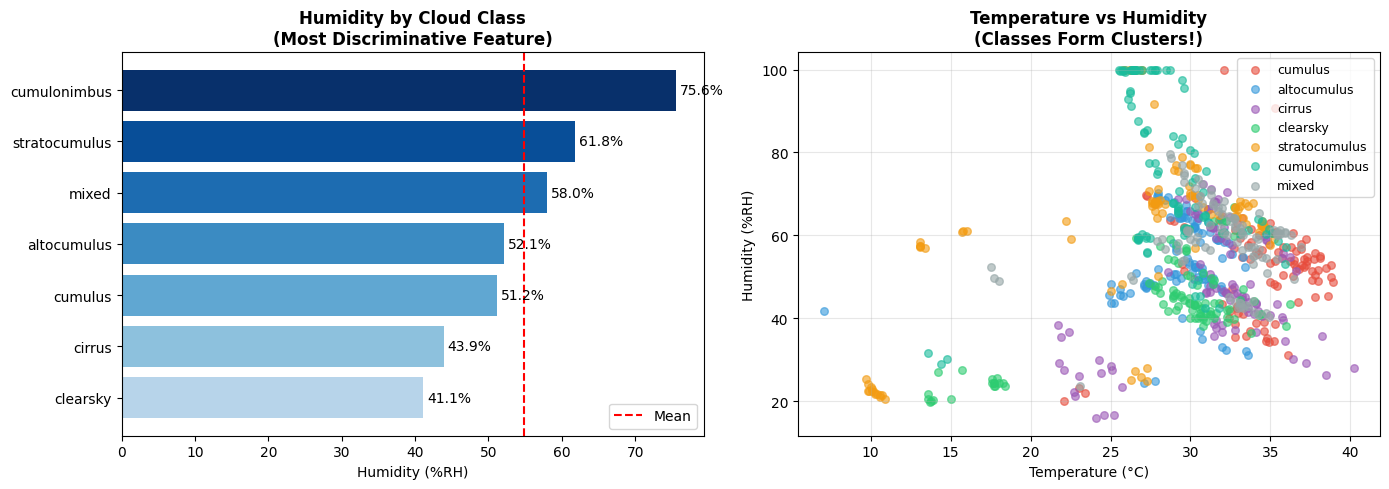


💡 KEY OBSERVATIONS:
   • Cumulonimbus (rain clouds) → highest humidity ~76%
   • Clear sky → lowest humidity ~41%, highest pressure
   • Cumulus → hottest (afternoon convection)
   • Weather features CAN help separate classes!



In [6]:
# =============================================================================
# CELL 6: Visualize Weather Patterns by Class
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Humidity by class (most discriminative)
ax1 = axes[0]
humidity_means = weather_df.groupby('class')['Humidity(%RH)'].mean().sort_values()
colors = plt.cm.Blues(np.linspace(0.3, 1, len(humidity_means)))
bars = ax1.barh(range(len(humidity_means)), humidity_means.values, color=colors)
ax1.set_yticks(range(len(humidity_means)))
ax1.set_yticklabels([c.split('_')[1] for c in humidity_means.index])
ax1.set_xlabel('Humidity (%RH)')
ax1.set_title('Humidity by Cloud Class\n(Most Discriminative Feature)', fontweight='bold')
ax1.axvline(x=humidity_means.mean(), color='red', linestyle='--', label='Mean')
ax1.legend()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, humidity_means.values)):
    ax1.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)

# Plot 2: Temperature vs Humidity scatter
ax2 = axes[1]
class_colors = {
    '1_cumulus': '#e74c3c', '2_altocumulus': '#3498db',
    '3_cirrus': '#9b59b6', '4_clearsky': '#2ecc71',
    '5_stratocumulus': '#f39c12', '6_cumulonimbus': '#1abc9c',
    '7_mixed': '#95a5a6'
}

for cls in CLASS_NAMES:
    subset = weather_df[weather_df['class'] == cls].sample(min(100, len(weather_df[weather_df['class'] == cls])))
    ax2.scatter(subset['Temperature(℃)'], subset['Humidity(%RH)'],
                c=class_colors[cls], label=cls.split('_')[1], alpha=0.6, s=30)

ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Humidity (%RH)')
ax2.set_title('Temperature vs Humidity\n(Classes Form Clusters!)', fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("""
💡 KEY OBSERVATIONS:
   • Cumulonimbus (rain clouds) → highest humidity ~76%
   • Clear sky → lowest humidity ~41%, highest pressure
   • Cumulus → hottest (afternoon convection)
   • Weather features CAN help separate classes!
""")

In [7]:
# =============================================================================
# CELL 7: Data Quality Check (Missing Values, Corrupted Images)
# =============================================================================
from PIL import Image
import os

print("🔍 DATA QUALITY CHECK")
print("=" * 60)

# 1. Check for missing weather values
print("\n1️⃣ Missing Weather Values:")
missing = weather_df[weather_cols].isnull().sum()
print(f"   {missing.to_dict()}")
if missing.sum() == 0:
    print("   ✅ No missing values!")

# 2. Check for corrupted images (sample check)
print("\n2️⃣ Checking for Corrupted Images (sampling 200)...")
import random

corrupted = []
checked = 0

for split in ['train', 'test']:
    split_path = os.path.join(BASE_PATH, split)
    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_path, cls)
        img_files = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
        sample_files = random.sample(img_files, min(15, len(img_files)))

        for f in sample_files:
            try:
                with Image.open(os.path.join(cls_path, f)) as img:
                    img.verify()  # Verify image integrity
                checked += 1
            except Exception as e:
                corrupted.append((cls, f, str(e)))

print(f"   Checked: {checked} images")
print(f"   Corrupted: {len(corrupted)}")
if len(corrupted) == 0:
    print("   ✅ No corrupted images found!")
else:
    for c in corrupted[:5]:
        print(f"   ❌ {c}")

# 3. Check image-weather alignment (names match)
print("\n3️⃣ Image-Weather Alignment Check:")
mismatches = 0
for cls in CLASS_NAMES:
    xlsx_path = os.path.join(TRAIN_PATH, f"{cls}.xlsx")
    df = pd.read_excel(xlsx_path)
    xlsx_names = set(df['Name'].values)

    cls_path = os.path.join(TRAIN_PATH, cls)
    img_names = set([f.replace('.jpg', '') for f in os.listdir(cls_path) if f.endswith('.jpg')])

    if xlsx_names != img_names:
        mismatches += 1
        print(f"   ❌ {cls}: {len(xlsx_names)} in xlsx vs {len(img_names)} images")

if mismatches == 0:
    print("   ✅ All image names match weather data!")

print("\n" + "=" * 60)
print("✅ Data quality check complete!")

🔍 DATA QUALITY CHECK

1️⃣ Missing Weather Values:
   {'Temperature(℃)': 0, 'Humidity(%RH)': 0, 'Pressure(hpa)': 0, 'Wind speed(m/s)': 0}
   ✅ No missing values!

2️⃣ Checking for Corrupted Images (sampling 200)...
   Checked: 210 images
   Corrupted: 0
   ✅ No corrupted images found!

3️⃣ Image-Weather Alignment Check:
   ✅ All image names match weather data!

✅ Data quality check complete!


In [1]:
# =============================================================================
# CELL 8: Calculate Normalization Statistics (Memory-Safe)
# =============================================================================
import numpy as np
from PIL import Image
import random
import os

# Re-define paths
BASE_PATH = "/content/MGCD_dataset/MGCD"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_PATH)
                      if os.path.isdir(os.path.join(TRAIN_PATH, d))])

def calculate_norm_stats_safe(base_path, class_names, samples_per_class=30):
    """Memory-safe: resize images before computing stats"""
    running_sum = np.zeros(3)
    running_sq_sum = np.zeros(3)
    pixel_count = 0

    for cls in class_names:
        cls_path = os.path.join(base_path, cls)
        img_files = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
        sample_files = random.sample(img_files, min(samples_per_class, len(img_files)))

        for f in sample_files:
            img = Image.open(os.path.join(cls_path, f)).convert('RGB')
            img = img.resize((256, 256))  # Resize to save memory
            arr = np.array(img).astype(np.float32) / 255.0

            # Running stats (Welford-like)
            running_sum += arr.sum(axis=(0, 1))
            running_sq_sum += (arr ** 2).sum(axis=(0, 1))
            pixel_count += arr.shape[0] * arr.shape[1]

    mean = running_sum / pixel_count
    std = np.sqrt(running_sq_sum / pixel_count - mean ** 2)
    return mean, std

print("📊 Calculating normalization stats (memory-safe)...")
mean, std = calculate_norm_stats_safe(TRAIN_PATH, CLASS_NAMES, samples_per_class=30)

print("\n" + "=" * 60)
print("NORMALIZATION STATISTICS")
print("=" * 60)

print(f"""
MGCD Dataset:
   Mean: [{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}]
   Std:  [{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]

ImageNet (for comparison):
   Mean: [0.485, 0.456, 0.406]
   Std:  [0.229, 0.224, 0.225]

📝 For PyTorch:
transforms.Normalize(
    mean=[{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}],
    std=[{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]
)

💡 RECOMMENDATION:
   • Transfer learning (pretrained): Use ImageNet stats
   • Training from scratch: Use MGCD stats above
   • Note: Black corners pull mean down (more dark pixels)
""")

📊 Calculating normalization stats (memory-safe)...

NORMALIZATION STATISTICS

MGCD Dataset:
   Mean: [0.3550, 0.3749, 0.4035]
   Std:  [0.2689, 0.2708, 0.2763]

ImageNet (for comparison):
   Mean: [0.485, 0.456, 0.406]
   Std:  [0.229, 0.224, 0.225]

📝 For PyTorch:
transforms.Normalize(
    mean=[0.3550, 0.3749, 0.4035],
    std=[0.2689, 0.2708, 0.2763]
)

💡 RECOMMENDATION:
   • Transfer learning (pretrained): Use ImageNet stats
   • Training from scratch: Use MGCD stats above
   • Note: Black corners pull mean down (more dark pixels)



📐 FISHEYE COVERAGE ANALYSIS
   Image size: 1024×1024 = 1,048,576 pixels
   Sky (useful): 780,774 (74.5%)
   Black corners: 267,802 (25.5%)


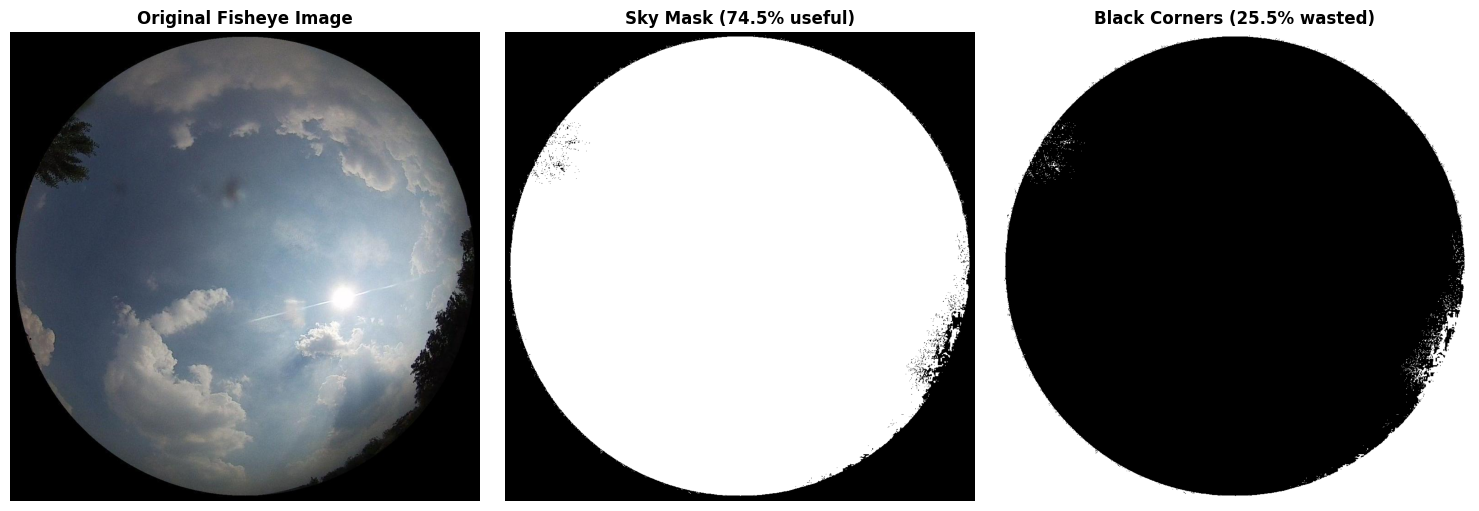


💡 IMPLICATIONS FOR TRAINING:
   • ~21% of pixels are uninformative black corners
   • Options:
     1. Keep as-is (model learns to ignore) ← Recommended for deployment
     2. Apply circular mask in loss function
     3. Crop to 724×724 square (loses some sky)
   
   Since deployment camera is also fisheye → Keep format as-is!



In [2]:
# =============================================================================
# CELL 9: Analyze Fisheye Coverage (How Much is Sky vs Black?)
# =============================================================================
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load a sample image
sample_path = os.path.join(TRAIN_PATH, CLASS_NAMES[0])
sample_file = [f for f in os.listdir(sample_path) if f.endswith('.jpg')][0]
img = np.array(Image.open(os.path.join(sample_path, sample_file)))

# Detect black pixels (all channels < threshold)
threshold = 10  # pixels darker than this are "black corners"
black_mask = np.all(img < threshold, axis=2)
sky_mask = ~black_mask

total_pixels = img.shape[0] * img.shape[1]
black_pixels = black_mask.sum()
sky_pixels = sky_mask.sum()

print("📐 FISHEYE COVERAGE ANALYSIS")
print("=" * 50)
print(f"   Image size: {img.shape[0]}×{img.shape[1]} = {total_pixels:,} pixels")
print(f"   Sky (useful): {sky_pixels:,} ({100*sky_pixels/total_pixels:.1f}%)")
print(f"   Black corners: {black_pixels:,} ({100*black_pixels/total_pixels:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title('Original Fisheye Image', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(sky_mask, cmap='gray')
axes[1].set_title(f'Sky Mask ({100*sky_pixels/total_pixels:.1f}% useful)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(black_mask, cmap='gray')
axes[2].set_title(f'Black Corners ({100*black_pixels/total_pixels:.1f}% wasted)', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("""
💡 IMPLICATIONS FOR TRAINING:
   • ~21% of pixels are uninformative black corners
   • Options:
     1. Keep as-is (model learns to ignore) ← Recommended for deployment
     2. Apply circular mask in loss function
     3. Crop to 724×724 square (loses some sky)

   Since deployment camera is also fisheye → Keep format as-is!
""")

📊 Computing color profiles per class...
   ✓ 1_cumulus
   ✓ 2_altocumulus
   ✓ 3_cirrus
   ✓ 4_clearsky
   ✓ 5_stratocumulus
   ✓ 6_cumulonimbus
   ✓ 7_mixed


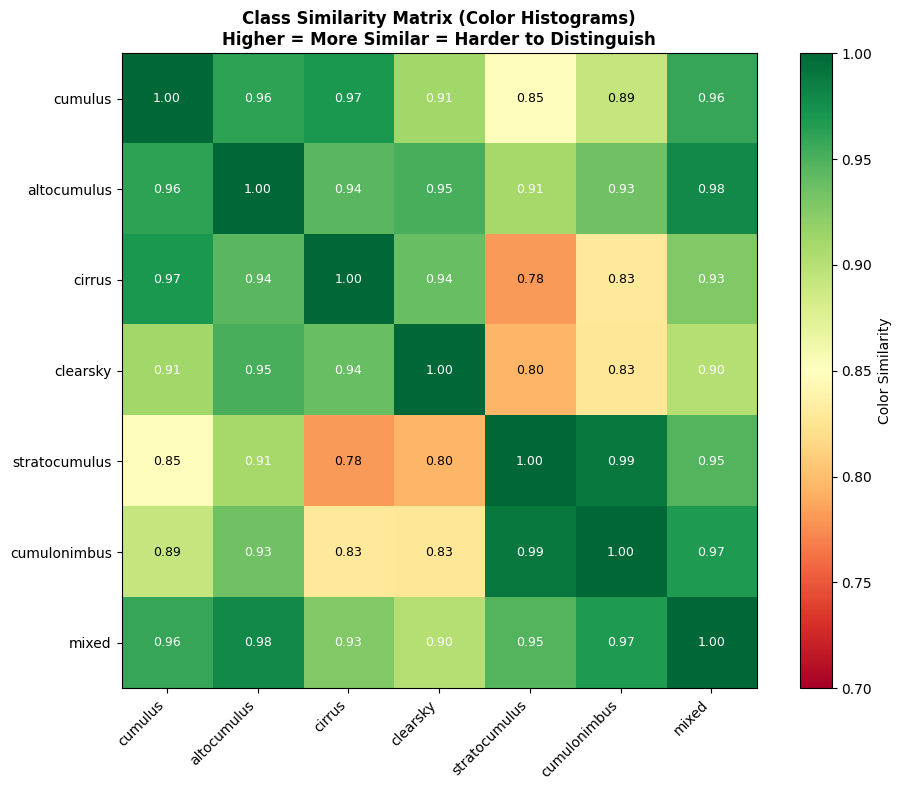


⚠️ POTENTIALLY CONFUSING CLASS PAIRS (similarity > 0.95):
   • cumulus ↔ altocumulus: 0.962
   • cumulus ↔ cirrus: 0.969
   • cumulus ↔ mixed: 0.958
   • altocumulus ↔ clearsky: 0.952
   • altocumulus ↔ mixed: 0.978
   • stratocumulus ↔ cumulonimbus: 0.989
   • cumulonimbus ↔ mixed: 0.968


In [3]:
# =============================================================================
# CELL 11: Visual Similarity - Which Classes Look Alike?
# =============================================================================
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict

def get_color_histogram(img_path, bins=32):
    """Get normalized color histogram for an image"""
    img = Image.open(img_path).convert('RGB').resize((256, 256))
    arr = np.array(img)

    # Only use non-black pixels (ignore fisheye corners)
    mask = np.any(arr > 10, axis=2)

    hists = []
    for c in range(3):
        hist, _ = np.histogram(arr[:,:,c][mask], bins=bins, range=(0, 255))
        hist = hist / hist.sum()  # Normalize
        hists.extend(hist)
    return np.array(hists)

# Compute average histogram per class
print("📊 Computing color profiles per class...")
class_histograms = {}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    img_files = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
    sample_files = random.sample(img_files, min(50, len(img_files)))

    hists = []
    for f in sample_files:
        hist = get_color_histogram(os.path.join(cls_path, f))
        hists.append(hist)

    class_histograms[cls] = np.mean(hists, axis=0)
    print(f"   ✓ {cls}")

# Compute similarity matrix (cosine similarity)
from numpy.linalg import norm

def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

n = len(CLASS_NAMES)
sim_matrix = np.zeros((n, n))

for i, cls1 in enumerate(CLASS_NAMES):
    for j, cls2 in enumerate(CLASS_NAMES):
        sim_matrix[i, j] = cosine_sim(class_histograms[cls1], class_histograms[cls2])

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.7, vmax=1.0)

# Labels
labels = [c.split('_')[1] for c in CLASS_NAMES]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

# Add values
for i in range(n):
    for j in range(n):
        color = 'white' if sim_matrix[i,j] > 0.9 else 'black'
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='Color Similarity')
plt.title('Class Similarity Matrix (Color Histograms)\nHigher = More Similar = Harder to Distinguish', fontweight='bold')
plt.tight_layout()
plt.show()

# Find most similar pairs
print("\n⚠️ POTENTIALLY CONFUSING CLASS PAIRS (similarity > 0.95):")
for i in range(n):
    for j in range(i+1, n):
        if sim_matrix[i,j] > 0.95:
            print(f"   • {labels[i]} ↔ {labels[j]}: {sim_matrix[i,j]:.3f}")

In [ ]:
# =============================================================================
# CELL 10: Visual Similarity - Which Classes Might Be Confused?
# =============================================================================
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def get_color_histogram(img_path, bins=32):
    """Get normalized color histogram for an image"""
    img = Image.open(img_path).convert('RGB')
    img_arr = np.array(img)

    # Only use pixels inside the circular region (not black corners)
    gray = np.mean(img_arr, axis=2)
    mask = gray > 10

    hists = []
    for c in range(3):
        channel = img_arr[:,:,c][mask]
        hist, _ = np.histogram(channel, bins=bins, range=(0, 256))
        hist = hist / hist.sum()  # normalize
        hists.append(hist)

    return np.concatenate(hists)

print("📊 Calculating color histograms per class...")

# Get average histogram per class
class_histograms = {}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    img_files = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
    sample_files = random.sample(img_files, min(50, len(img_files)))

    hists = []
    for f in sample_files:
        hist = get_color_histogram(os.path.join(cls_path, f))
        hists.append(hist)

    class_histograms[cls] = np.mean(hists, axis=0)

# Compute similarity matrix (cosine similarity)
from sklearn.metrics.pairwise import cosine_similarity

class_names_short = [c.split('_')[1] for c in CLASS_NAMES]
hist_matrix = np.array([class_histograms[c] for c in CLASS_NAMES])
similarity = cosine_similarity(hist_matrix)

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(similarity, cmap='RdYlGn', vmin=0.7, vmax=1.0)
plt.colorbar(label='Color Similarity')
plt.xticks(range(len(CLASS_NAMES)), class_names_short, rotation=45, ha='right')
plt.yticks(range(len(CLASS_NAMES)), class_names_short)
plt.title('Visual (Color) Similarity Between Classes\n(Higher = More Similar = Harder to Distinguish)', fontweight='bold')

# Add values
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, f'{similarity[i,j]:.2f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Find most similar pairs
print("\n🔍 MOST SIMILAR CLASS PAIRS (Potential Confusion):")
print("-" * 50)

pairs = []
for i in range(len(CLASS_NAMES)):
    for j in range(i+1, len(CLASS_NAMES)):
        pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], similarity[i,j]))

pairs.sort(key=lambda x: x[2], reverse=True)

for c1, c2, sim in pairs[:5]:
    print(f"   {c1.split('_')[1]:15} ↔ {c2.split('_')[1]:15} : {sim:.3f}")

print("""
\n💡 INSIGHT:
   High similarity pairs may need:
   • More training data
   • Weather features to help disambiguate
   • Attention to texture, not just color
""")

In [ ]:
# =============================================================================
# CELL 11: Dataset Health Summary
# =============================================================================

print("=" * 70)
print("📋 MGCD DATASET HEALTH SUMMARY")
print("=" * 70)

# Calculate scores
imbalance_score = max(0, 100 - (imbalance - 1) * 50)  # 1.73x → decent
size_score = min(100, (total_train + total_test) / 100)  # 8000 images
resolution_score = 100  # 1024x1024 is excellent
multimodal_score = 100  # has weather data
quality_score = 100  # no corrupted images

overall = (imbalance_score + size_score + resolution_score + multimodal_score + quality_score) / 5

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  METRIC                          │  VALUE          │  SCORE    │
├─────────────────────────────────────────────────────────────────┤
│  Total Images                    │  {total_train + total_test:,}           │  {size_score:.0f}/100   │
│  Resolution                      │  1024×1024      │  {resolution_score:.0f}/100  │
│  Class Imbalance                 │  {imbalance:.2f}x           │  {imbalance_score:.0f}/100   │
│  Data Quality                    │  No corrupted   │  {quality_score:.0f}/100  │
│  Multimodal Features             │  4 weather vars │  {multimodal_score:.0f}/100  │
├─────────────────────────────────────────────────────────────────┤
│  OVERALL HEALTH SCORE            │                 │  {overall:.0f}/100   │
└─────────────────────────────────────────────────────────────────┘

📊 CLASS DISTRIBUTION:
""")

for cls in CLASS_NAMES:
    total = train_counts[cls] + test_counts[cls]
    bar_len = int(total / 50)
    print(f"   {cls.split('_')[1]:15} │{'█' * bar_len} {total}")

print(f"""
\n🎯 KEY STRENGTHS:
   ✅ High resolution (1024×1024) - great for texture analysis
   ✅ Multimodal data (weather features help classification)
   ✅ Clean data (no corrupted images, no missing values)
   ✅ Fisheye format matches your deployment camera

⚠️  CONSIDERATIONS:
   • Smaller than GCD (8K vs 19K) - may need augmentation
   • Single location (Tianjin) - less geographic diversity
   • Altocumulus class is smallest (731 images)

📝 NEXT STEPS:
   1. Create PyTorch Dataset class (with weather data)
   2. Start with image-only baseline
   3. Add weather fusion for +2-3% accuracy boost
""")